In [121]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

SEED = 123456
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [122]:
# Load data
df = pd.read_csv('tesla_stock_data.csv')
df["Date"] = pd.to_datetime(df["Date"])
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2015-09-21,17.598667,18.104668,17.053333,17.613333,91803000,0.0,0.0
1,2015-09-22,17.268667,17.510000,17.058001,17.396000,54966000,0.0,0.0
2,2015-09-23,17.463333,17.472000,17.172001,17.403999,39012000,0.0,0.0
3,2015-09-24,17.302000,17.563334,17.080667,17.541332,51723000,0.0,0.0
4,2015-09-25,17.774000,17.794001,17.076668,17.127333,56601000,0.0,0.0
...,...,...,...,...,...,...,...,...
2510,2025-09-15,423.130005,425.700012,402.429993,410.040009,163823700,0.0,0.0
2511,2025-09-16,414.500000,423.250000,411.429993,421.619995,104285700,0.0,0.0
2512,2025-09-17,415.750000,428.309998,409.670013,425.859985,106133500,0.0,0.0
2513,2025-09-18,428.869995,432.220001,416.559998,416.850006,90454500,0.0,0.0


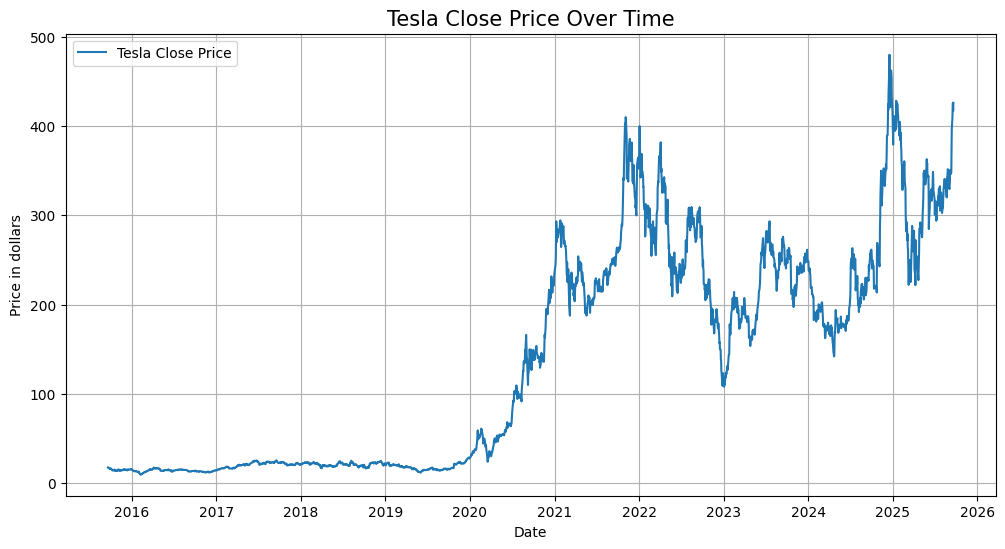

In [123]:
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"], label="Tesla Close Price")
plt.title("Tesla Close Price Over Time", fontsize=15)
plt.ylabel("Price in dollars")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

In [124]:
# Preparing Train data and Test data
features = ["Open", "High", "Low", "Close", "Volume"]
target = "Close"

data = df[features].values

train_df = df[df["Date"] <="2025-09-18"]
test_df = df[df["Date"] >= "2025-06-2"]

train_data = train_df[features].values
test_data = test_df[features].values

# Normalize
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)


# Create_sequence(data, window_size=60)
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size: i])
        y.append(data[i, 3])
    return np.array(X), np.array(y)

window_size = 90

X_train, y_train = create_sequences(train_scaled, window_size)
X_test, y_test = create_sequences(test_scaled, window_size)

print("X_train shape:", X_train.shape)
print("Y_train shape:", y_train.shape)

X_train shape: (2424, 90, 5)
Y_train shape: (2424,)


In [125]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(window_size, len(features))),
    Dropout(0.3),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dense(1)
])

optimizer = Adam(learning_rate = 0.1, beta_1 = 0.5)
model.compile(optimizer = optimizer, loss="mse")
model.summary()

d:\Work\AI\TopAIProject\3. StockPricePrediction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_23 (LSTM)                  │ (None, 90, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 90, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_24 (LSTM)                  │ (None, 90, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 90, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_25 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 249,665 (975.25 KB)

 Trainable params: 249,665 (975.25 KB)

 Non-trainable params: 0 (0.00 B)

In [126]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stop]
)

Epoch 1/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - loss: 0.3329 - val_loss: 0.0170
Epoch 2/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.1037 - val_loss: 0.3463
Epoch 3/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.2082 - val_loss: 0.1528
Epoch 4/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.2023 - val_loss: 0.1408
Epoch 5/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.2082 - val_loss: 0.1971
Epoch 6/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.1938 - val_loss: 0.0401
Epoch 7/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0934 - val_loss: 0.1982
Epoch 8/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.1763 - val_loss: 0.2127
Epoch 9/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.1897 - val_loss: 0.2015
Epoch 10/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.1788 - val_loss: 0.0553
Epoch 11/200
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - loss: 0.1054 - val_loss: 0.1459


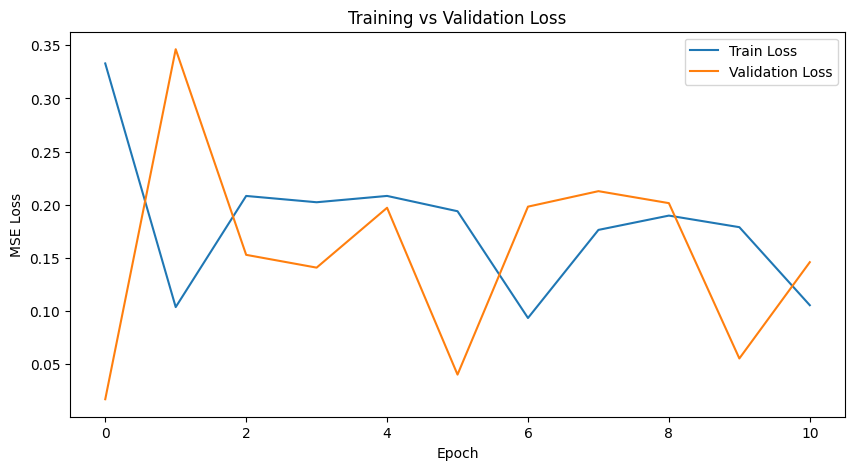

In [127]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [128]:
# test_loss = model.evaluate(X_test, y_test)
# print("Test MSE Loss:", test_loss)

In [129]:
# y_pred_scaled = model.predict(X_test)

In [130]:
# # Empty array with same number of columns as original features
# y_pred_extended = np.zeros((len(y_pred_scaled), len(features)))
# y_test_extended = np.zeros((len(y_test), len(features)))

# # Put predictions (and true values) into the "Close" column (index 3)
# y_pred_extended[:, 3] = y_pred_scaled[:, 0]   # model output
# y_test_extended[:, 3] = y_test                # true close

# # Inverse transform
# y_pred_real = scaler.inverse_transform(y_pred_extended)[:, 3]
# y_test_real = scaler.inverse_transform(y_test_extended)[:, 3]

In [131]:
# plt.figure(figsize=(12,6))
# plt.plot(y_test_real, label="Actual Closing Price")
# plt.plot(y_pred_real, label="Predicted Closing Price")
# plt.xlabel("Time (days in test set)")
# plt.ylabel("Tesla Close Price (USD)")
# plt.title("Tesla Stock Price Prediction")
# plt.legend()
# plt.show()

In [132]:
# Adding One New Day

# 421.820007	429.470001	421.720001	426.070007	92847900	
new_data = pd.DataFrame({ "Open": [421.820007], "High": [429.470001], "Low": [421.720001], "Close": [426.070007], "Volume": [92847900]})
new_data_values= new_data[features].values

# Normalize using the existing scaler
new_scaled = scaler.transform(new_data_values)

# train_scaled = np.vstack([train_scaled, new_scaled])



In [137]:
# The next day price prediction

# last_sequence = train_scaled[-90:]

# X_train, y_train = create_sequences(train_scaled[-90:], window_size)

y_pred = model.predict(X_train[-1:])

print(y_train, y_pred)

# X_new = np.vstack([last_sequence, new_scaled])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[0.0067378  0.0075515  0.00554419 ... 0.87615943 0.88517527 0.8660166 ] [[0.6978559]]


In [138]:
print(X_train)

[[[0.01738949 0.01625511 0.01707183 0.0170862  0.08985768]
  [0.01668196 0.01501158 0.01708224 0.01662407 0.04908452]
  [0.01709933 0.01493212 0.01733665 0.01664108 0.03142578]
  ...
  [0.00777281 0.00597368 0.00711587 0.00707235 0.07066484]
  [0.00715533 0.00533798 0.00665318 0.0062941  0.04830087]
  [0.00692807 0.00506195 0.0061533  0.00652516 0.06449856]]

 [[0.01668196 0.01501158 0.01708224 0.01662407 0.04908452]
  [0.01709933 0.01493212 0.01733665 0.01664108 0.03142578]
  [0.01675343 0.01512311 0.01713283 0.0169331  0.045495  ]
  ...
  [0.00715533 0.00533798 0.00665318 0.0062941  0.04830087]
  [0.00692807 0.00506195 0.0061533  0.00652516 0.06449856]
  [0.006808   0.00540489 0.00699685 0.0067378  0.03560139]]

 [[0.01709933 0.01493212 0.01733665 0.01664108 0.03142578]
  [0.01675343 0.01512311 0.01713283 0.0169331  0.045495  ]
  [0.01776541 0.01560546 0.0171239  0.01605278 0.05089423]
  ...
  [0.00692807 0.00506195 0.0061533  0.00652516 0.06449856]
  [0.006808   0.00540489 0.0069968